# **EVALUATION**

Mengukur seberapa besar distorsi yang ditimbulkan proses embedding terhadap cover (fidelity), <br>
lalu menguji seberapa tahan watermark terhadap gangguan (robustness). tahapan sebagai berikut:
1. Fidelity: MSE, PSNR, dan SSIM
- MSE (Mean Squared Error) rata-rata kuadrat selisih piksel. Makin kecil, makin mirip. Satuan mentah, sulit diinterpretasi sendiri tapi dasar perhitungan PSNR.
- PSNR (Peak Signal-to-Noise Ratio) dalam dB, makin tinggi makin bagus. Umumnya PSNR > 40 dB dianggap distorsi tidak terlihat mata manusia. (Ini metrik paling umum dipakai di paper watermarking).
- SSIM (Structural Similarity Index) mengukur kemiripan struktural (bukan cuma piksel per piksel), rentang 0–1, makin dekat ke 1 makin mirip secara persepsi visual manusia.

2. Robustness Testing — uji ketahanan watermark
3. Efisiensi (opsional, tapi mudah ditambahkan)

In [29]:
%pip install scikit-image pandas

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

Note: you may need to restart the kernel to use updated packages.


In [20]:
# --- baca cover asli (berwarna) ---
cover = cv2.imread('../data/raw/cover-hostimage.jpg')
if cover is None:
    raise FileNotFoundError("Cover tidak ditemukan.")

# --- baca watermarked images (hasil embedding, dari disk) ---
watermarked_small  = cv2.imread('../data/watermarked/watermarked_small.png')
watermarked_medium = cv2.imread('../data/watermarked/watermarked_medium.png')
watermarked_high   = cv2.imread('../data/watermarked/watermarked_high.png')

for name, img in [("small", watermarked_small), ("medium", watermarked_medium), ("high", watermarked_high)]:
    if img is None:
        raise FileNotFoundError(f"Watermarked image '{name}' tidak ditemukan atau gagal dibaca.")

# watermark ASLI (untuk pembanding akurasi)
logo1_small_bw  = cv2.imread("../data/resize/resize_small_payload.png", 0)
logo2_medium_bw = cv2.imread("../data/resize/resize_medium_payload.png", 0)
logo3_high_bw   = cv2.imread("../data/resize/resize_high_payload.png", 0)

for name, img in [("small", logo1_small_bw), ("medium", logo2_medium_bw), ("high", logo3_high_bw)]:
    if img is None:
        raise FileNotFoundError(f"Watermark asli '{name}' tidak ditemukan.")

watermark1_bit_original = logo1_small_bw // 255
watermark2_bit_original = logo2_medium_bw // 255
watermark3_bit_original = logo3_high_bw // 255

h1, w1 = logo1_small_bw.shape
h2, w2 = logo2_medium_bw.shape
h3, w3 = logo3_high_bw.shape


In [21]:
# --- FUNGSI EKSTRAKSI (didefinisikan ulang di file ini) ---
def extract_lsb(watermarked_img, h, w, channel=0):
    """
    Ekstrak watermark dari LSB salah satu channel warna watermarked_img.
    channel: 0 = Blue, 1 = Green, 2 = Red (urutan OpenCV/BGR).
    HARUS SAMA dengan channel yang dipakai saat embedding.
    """
    assert watermarked_img.ndim == 3, "watermarked_img harus gambar berwarna (3 channel)"

    region = watermarked_img[0:h, 0:w, channel]
    extracted_bit = region & 1
    extracted_bw = extracted_bit * 255

    return extracted_bit, extracted_bw

In [17]:
# --- FIDELITY ---
# kalkulasi mse
def calc_mse(img1, img2):
    # Hitung MSE antara dua gambar (harus sama ukuran & channel)
    assert img1.shape == img2.shape, f"Shape tidak sama: {img1.shape} vs {img2.shape}"
    err = np.mean((img1.astype("float") - img2.astype("float")) ** 2)
    return err

# kalkulasi pnsr
def calc_psnr(img1, img2, max_pixel=255.0):
    # Hitung PSNR (dB) berdasarkan MSE
    mse = calc_mse(img1, img2)
    if mse == 0:
        return float('inf')  # identik sempurna
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# kalkulasi ssim
def calc_ssim(img1, img2):
    # Hitung SSIM. Untuk gambar berwarna, hitung per channel lalu rata-rata
    assert img1.shape == img2.shape
    if img1.ndim == 3:
        return ssim(img1, img2, channel_axis=2)
    else:
        return ssim(img1, img2)

# --- hitung untuk ketiga watermarked image vs cover asli ---
results = {}
for label, wimg in [("Small", watermarked_small), ("Medium", watermarked_medium), ("High", watermarked_high)]:
    mse_val  = calc_mse(cover, wimg)
    psnr_val = calc_psnr(cover, wimg)
    ssim_val = calc_ssim(cover, wimg)
    results[label] = {"MSE": mse_val, "PSNR": psnr_val, "SSIM": ssim_val}
    print(f"[{label}] MSE: {mse_val:.6f} | PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.6f}")

[Small] MSE: 0.000101 | PSNR: 88.10 dB | SSIM: 0.999999
[Medium] MSE: 0.001683 | PSNR: 75.87 dB | SSIM: 0.999991
[High] MSE: 0.006885 | PSNR: 69.75 dB | SSIM: 0.999970


In [25]:
# --- ROBUSTNESS TESTING ---
# Fungsi-fungsi serangan (ATTACK)
def attack_jpeg_compression(img, quality=50):
    # Simulasi kompresi JPEG (lossy) dengan kualitas tertentu (1-100).
    encode_param = [cv2.IMWRITE_JPEG_QUALITY, quality]
    _, encoded = cv2.imencode('.jpg', img, encode_param)
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    return decoded

def attack_gaussian_noise(img, mean=0, sigma=10):
    # Tambahkan noise Gaussian.
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def attack_salt_pepper(img, amount=0.01):
    # Tambahkan noise salt & pepper.
    noisy = img.copy()
    num_salt = int(amount * img.size * 0.5)

    coords = [np.random.randint(0, i, num_salt) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 255

    coords = [np.random.randint(0, i, num_salt) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 0

    return noisy

def attack_crop(img, crop_ratio=0.1):
    # Crop sebagian tepi gambar lalu resize balik ke ukuran semula.
    h, w = img.shape[:2]
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    cropped = img[ch:h-ch, cw:w-cw]
    return cv2.resize(cropped, (w, h))

def attack_rotation(img, angle=5):
    # Rotasi gambar sedikit lalu kembalikan ke ukuran semula.
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, matrix, (w, h))
    return rotated

# Fungsi uji robustness (reusable untuk semua payload)
def test_robustness(watermarked_img, original_bit, h, w, label, channel=0):
    # Uji watermarked_img dengan berbagai serangan, lalu ekstrak & hitung akurasi dibandingkan watermark asli (original_bit).
    attacks = {
        "Original (tanpa serangan)": watermarked_img,
        "JPEG Q=90":  attack_jpeg_compression(watermarked_img, quality=90),
        "JPEG Q=50":  attack_jpeg_compression(watermarked_img, quality=50),
        "JPEG Q=10":  attack_jpeg_compression(watermarked_img, quality=10),
        "Gaussian Noise (sigma=10)": attack_gaussian_noise(watermarked_img, sigma=10),
        "Salt & Pepper Noise": attack_salt_pepper(watermarked_img, amount=0.01),
        "Crop 10%": attack_crop(watermarked_img, crop_ratio=0.1),
        "Rotasi 5°": attack_rotation(watermarked_img, angle=5),
    }

    results = {}
    extracted_images = {}

    print(f"\n=== UJI ROBUSTNESS - WATERMARK {label.upper()} ===")
    for attack_name, attacked_img in attacks.items():
        extracted_bit, extracted_bw = extract_lsb(attacked_img, h, w, channel=channel)
        accuracy = np.sum(original_bit == extracted_bit) / original_bit.size * 100
        results[attack_name] = accuracy
        extracted_images[attack_name] = extracted_bw
        print(f"  [{attack_name}] Akurasi: {accuracy:.2f}%")

    return results, extracted_images


# ============================================
# 5. JALANKAN UJI ROBUSTNESS UNTUK KETIGA PAYLOAD
# ============================================
robustness_small, extracted_small_imgs = test_robustness(
    watermarked_small, watermark1_bit_original, h1, w1, "Small"
)
robustness_medium, extracted_medium_imgs = test_robustness(
    watermarked_medium, watermark2_bit_original, h2, w2, "Medium"
)
robustness_high, extracted_high_imgs = test_robustness(
    watermarked_high, watermark3_bit_original, h3, w3, "High"
)


=== UJI ROBUSTNESS - WATERMARK SMALL ===
  [Original (tanpa serangan)] Akurasi: 100.00%
  [JPEG Q=90] Akurasi: 71.77%
  [JPEG Q=50] Akurasi: 98.07%
  [JPEG Q=10] Akurasi: 99.24%
  [Gaussian Noise (sigma=10)] Akurasi: 49.83%
  [Salt & Pepper Noise] Akurasi: 98.68%
  [Crop 10%] Akurasi: 43.72%
  [Rotasi 5°] Akurasi: 0.76%

=== UJI ROBUSTNESS - WATERMARK MEDIUM ===
  [Original (tanpa serangan)] Akurasi: 100.00%
  [JPEG Q=90] Akurasi: 55.89%
  [JPEG Q=50] Akurasi: 97.73%
  [JPEG Q=10] Akurasi: 99.10%
  [Gaussian Noise (sigma=10)] Akurasi: 50.03%
  [Salt & Pepper Noise] Akurasi: 98.53%
  [Crop 10%] Akurasi: 47.65%
  [Rotasi 5°] Akurasi: 50.52%

=== UJI ROBUSTNESS - WATERMARK HIGH ===
  [Original (tanpa serangan)] Akurasi: 100.00%
  [JPEG Q=90] Akurasi: 56.06%
  [JPEG Q=50] Akurasi: 78.17%
  [JPEG Q=10] Akurasi: 99.16%
  [Gaussian Noise (sigma=10)] Akurasi: 50.04%
  [Salt & Pepper Noise] Akurasi: 98.51%
  [Crop 10%] Akurasi: 67.34%
  [Rotasi 5°] Akurasi: 72.37%


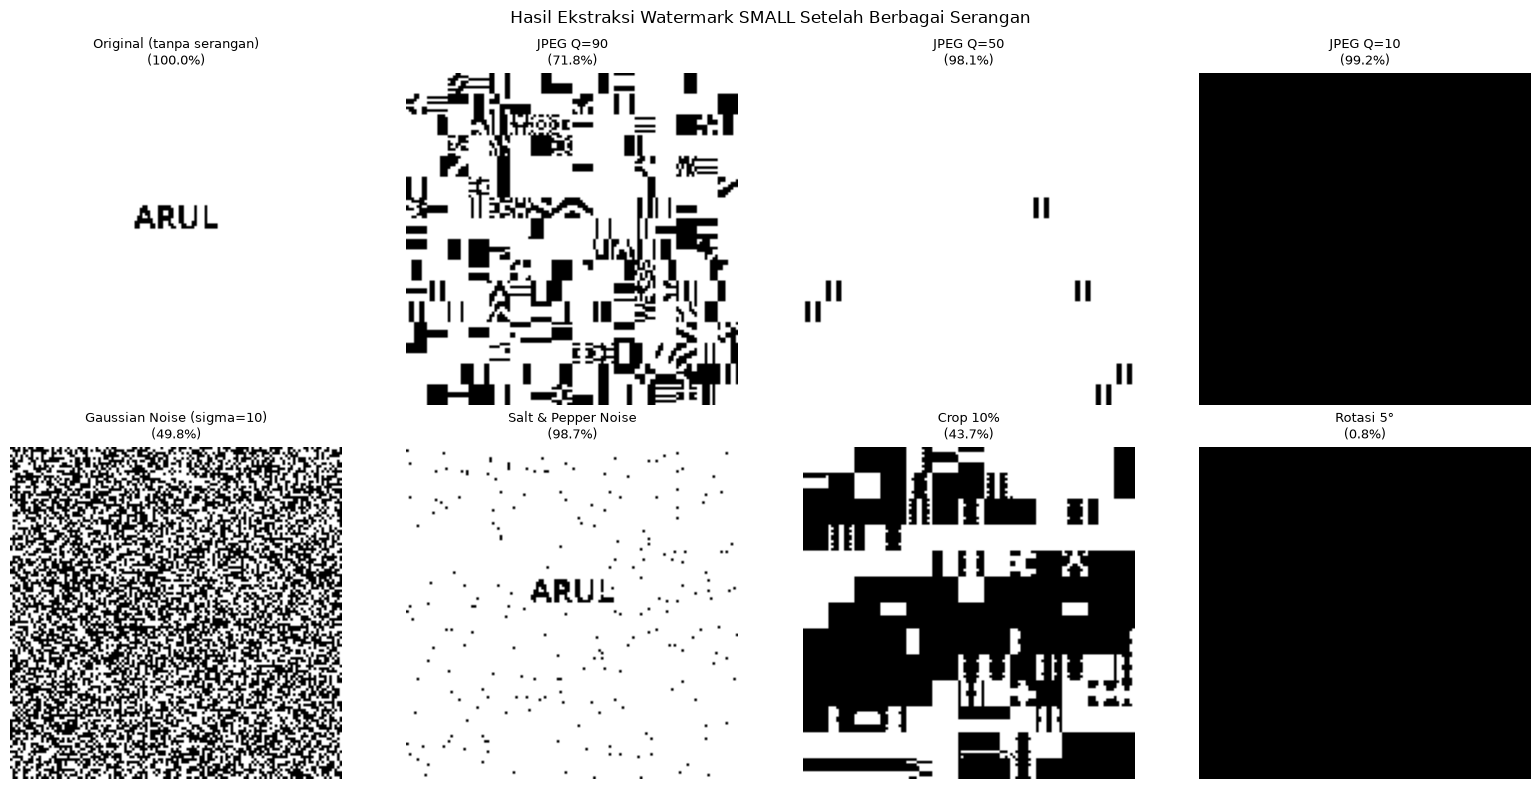


=== TABEL RINGKASAN ROBUSTNESS ===
                 Serangan  Small (%)  Medium (%)   High (%)
Original (tanpa serangan) 100.000000  100.000000 100.000000
                JPEG Q=90  71.771240   55.887604  56.059837
                JPEG Q=50  98.065186   97.732162  78.167725
                JPEG Q=10  99.237061   99.099731  99.162865
Gaussian Noise (sigma=10)  49.829102   50.029373  50.044632
      Salt & Pepper Noise  98.675537   98.528671  98.506069
                 Crop 10%  43.719482   47.653961  67.335606
                Rotasi 5°   0.762939   50.519943  72.365665


In [32]:
# --- VISUALISASI HASIL EKSTRAKSI SETELAH SERANGAN (contoh: payload Small) ---
attack_names = list(extracted_small_imgs.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, attack_name in zip(axes, attack_names):
    ax.imshow(extracted_small_imgs[attack_name], cmap='gray')
    ax.set_title(f"{attack_name}\n({robustness_small[attack_name]:.1f}%)", fontsize=9)
    ax.axis('off')

plt.suptitle("Hasil Ekstraksi Watermark SMALL Setelah Berbagai Serangan", fontsize=12)
plt.tight_layout()
plt.show()


# --- TABEL RINGKASAN ROBUSTNESS (semua payload) ---
summary_robustness = pd.DataFrame({
    "Serangan": list(robustness_small.keys()),
    "Small (%)": list(robustness_small.values()),
    "Medium (%)": list(robustness_medium.values()),
    "High (%)": list(robustness_high.values()),
})

print("\n=== TABEL RINGKASAN ROBUSTNESS ===")
print(summary_robustness.to_string(index=False))

summary_robustness.to_csv('../data/output/summary_robustness.csv', index=False)